# Story Writing Benchmark — 1. Alignment Metrics

## Setup

In [1]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy import stats
from IPython.display import display

sns.set_theme(style="whitegrid", font_scale=0.95)
plt.rcParams["figure.dpi"] = 120

RESULTS_DIR   = Path("../dataset/results")
LOGS_DIR      = Path("../logs")
BASELINE_FILE = "claude_sonnet_4.6_result.csv"

GPU_RATE_LOW  = 2.0   # $/hr (H100)
GPU_RATE_HIGH = 3.5
CLAUDE_PRICE_INPUT  = 3.0   # $/1M input tokens
CLAUDE_PRICE_OUTPUT = 15.0  # $/1M output tokens

SCORE_MIN, SCORE_MAX = 0, 5

ALL_CATEGORIES = [
    "Grammar, Spelling, and Punctuation Quality",
    "Clarity and Understandability",
    "Logical Connection Between Events and Ideas",
    "Scene Construction and Purpose",
    "Internal Consistency",
    "Character Consistency",
    "Character Motivation and Actions",
    "Sentence Pattern Variety",
    "Avoidance of Clichés and Overused Phrases",
    "Natural Dialogue",
    "Avoidance of Predictable Narrative Tropes",
    "Character Depth and Dimensionality",
    "Realistic Character Interactions",
    "Ability to Hold Reader Interest",
    "Satisfying Plot Resolution",
]
ALL_COLS = [f"{c}_score" for c in ALL_CATEGORIES]
KEYS     = ["index", "prompt_id", "model"]

def pretty_model(stem: str) -> str:
    return stem.replace("_swb_result", "").replace("_result", "")

## 1. Load data

In [2]:
ref = pd.read_csv(RESULTS_DIR / BASELINE_FILE)

evaluator_dfs = {}
for p in sorted(RESULTS_DIR.glob("*_result.csv")):
    if "claude" in p.name:
        continue
    name = pretty_model(p.stem)
    ev = pd.read_csv(p)
    m = pd.merge(ev, ref, on=KEYS, suffixes=("_ev", "_ref"), how="inner")
    evaluator_dfs[name] = m

print(f"Baseline: {BASELINE_FILE}  ({len(ref)} rows)")
for name, df in evaluator_dfs.items():
    print(f"  {name}: {len(df)} rows")

Baseline: claude_sonnet_4.6_result.csv  (3480 rows)
  Llama-3.2-3B-Instruct: 3480 rows
  NVIDIA-Nemotron-3-Nano-4B-BF16: 3480 rows
  Qwen3-4B-Instruct-2507: 3480 rows
  Qwen3.5-4B: 3480 rows
  gemma-4-E2B-it: 3480 rows
  gemma-4-E4B-it: 3480 rows


## 2. Alignment metrics

Per-model MAE, RMSE, Spearman ρ, Kendall τ vs Claude Sonnet 4.6 baseline.

In [3]:
summary_rows = []

for name, m in evaluator_dfs.items():
    all_diffs, all_ev, all_ref_vals = [], [], []

    for col in ALL_COLS:
        ev_s  = m[f"{col}_ev"].to_numpy(dtype=float)
        ref_s = m[f"{col}_ref"].to_numpy(dtype=float)
        mask  = ~(np.isnan(ev_s) | np.isnan(ref_s))
        diff  = ev_s[mask] - ref_s[mask]
        all_diffs.append(diff)
        all_ev.extend(ev_s[mask])
        all_ref_vals.extend(ref_s[mask])

    all_d = np.concatenate(all_diffs)
    rho, _ = stats.spearmanr(all_ev, all_ref_vals)
    tau, _ = stats.kendalltau(all_ev, all_ref_vals)

    summary_rows.append({
        "Model":       name,
        "MAE":         round(float(np.mean(np.abs(all_d))), 3),
        "RMSE":        round(float(np.sqrt(np.mean(all_d**2))), 3),
        "Spearman ρ":  round(float(rho), 3),
        "Kendall τ":   round(float(tau), 3),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("MAE").reset_index(drop=True)
display(summary_df)

print("\nLaTeX table rows:")
for _, r in summary_df.iterrows():
    print(f"{r['Model']:<35} & {r['MAE']:.3f} & {r['RMSE']:.3f} & {r['Spearman ρ']:.3f} & {r['Kendall τ']:.3f} \\\\")

,Model,MAE,RMSE,Spearman ρ,Kendall τ
0,Qwen3.5-4B,0.597,0.859,0.780,0.702
1,gemma-4-E2B-it,0.669,0.935,0.652,0.595
2,gemma-4-E4B-it,0.798,1.005,0.797,0.732
3,NVIDIA-Nemotron-3-Nano-4B-BF16,1.137,1.370,0.606,0.543
4,Qwen3-4B-Instruct-2507,1.522,1.706,0.648,0.588
5,Llama-3.2-3B-Instruct,1.980,2.225,0.231,0.210



LaTeX table rows:
Qwen3.5-4B                          & 0.597 & 0.859 & 0.780 & 0.702 \\
gemma-4-E2B-it                      & 0.669 & 0.935 & 0.652 & 0.595 \\
gemma-4-E4B-it                      & 0.798 & 1.005 & 0.797 & 0.732 \\
NVIDIA-Nemotron-3-Nano-4B-BF16      & 1.137 & 1.370 & 0.606 & 0.543 \\
Qwen3-4B-Instruct-2507              & 1.522 & 1.706 & 0.648 & 0.588 \\
Llama-3.2-3B-Instruct               & 1.980 & 2.225 & 0.231 & 0.210 \\


## 3. Per-category MAE heatmap

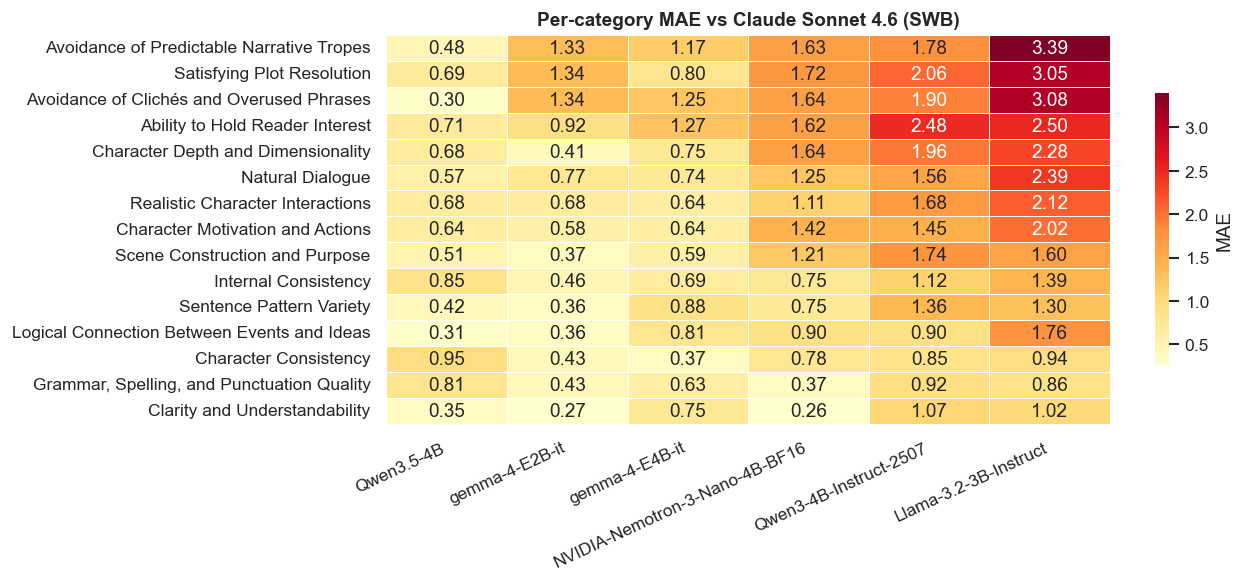

In [4]:
per_cat_rows = []
model_order = summary_df["Model"].tolist()

for name, m in evaluator_dfs.items():
    for col in ALL_COLS:
        ev_s  = m[f"{col}_ev"].to_numpy(dtype=float)
        ref_s = m[f"{col}_ref"].to_numpy(dtype=float)
        mask  = ~(np.isnan(ev_s) | np.isnan(ref_s))
        diff  = ev_s[mask] - ref_s[mask]
        per_cat_rows.append({
            "model":  name,
            "rubric": col.replace("_score", ""),
            "mae":    float(np.mean(np.abs(diff))),
        })

per_cat_df = pd.DataFrame(per_cat_rows)
pivot = per_cat_df.pivot(index="rubric", columns="model", values="mae")[model_order]
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax,
            linewidths=0.4, cbar_kws={"label": "MAE", "shrink": 0.7})
ax.set_title("Per-category MAE vs Claude Sonnet 4.6 (SWB)", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()